##IMPORTS


In [ ]:
import os
import torch
import torch.nn as nn
import pandas as pd

from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset , DataLoader
from transformers import AutoTokenizer , ViTModel , AutoModelForCausalLM

In [ ]:
image_dir = "/content/drive/MyDrive/Image_Caption/Images"
caption_dir = "/content/drive/MyDrive/Image_Caption/captions.txt"

In [ ]:
df = pd.read_csv(caption_dir)

print(df.head())
print(len(df))
print(df.columns.tolist())

                       image  \
0  1000268201_693b08cb0e.jpg   
1  1000268201_693b08cb0e.jpg   
2  1000268201_693b08cb0e.jpg   
3  1000268201_693b08cb0e.jpg   
4  1000268201_693b08cb0e.jpg   

                                             caption  
0  A child in a pink dress is climbing up a set o...  
1              A girl going into a wooden building .  
2   A little girl climbing into a wooden playhouse .  
3  A little girl climbing the stairs to her playh...  
4  A little girl in a pink dress going into a woo...  
40455
['image', 'caption']


In [ ]:
df["image_path"] = df["image"].apply(lambda x: os.path.join(image_dir , x))

print(df[["image" , "image_path"]].head())

                       image  \
0  1000268201_693b08cb0e.jpg   
1  1000268201_693b08cb0e.jpg   
2  1000268201_693b08cb0e.jpg   
3  1000268201_693b08cb0e.jpg   
4  1000268201_693b08cb0e.jpg   

                                          image_path  
0  /content/drive/MyDrive/Image_Caption/Images/10...  
1  /content/drive/MyDrive/Image_Caption/Images/10...  
2  /content/drive/MyDrive/Image_Caption/Images/10...  
3  /content/drive/MyDrive/Image_Caption/Images/10...  
4  /content/drive/MyDrive/Image_Caption/Images/10...  


In [ ]:
unique_images = df["image"].unique()

print("Unique Images" , len(unique_images))
print("Total Caption rows" , len(df))

Unique Images 8091
Total Caption rows 40455


##TRAIN-TEST SPLIT

In [ ]:
# ============================================
# Use only 1,000 unique images
# ============================================

from sklearn.model_selection import train_test_split

# Get unique images
unique_images = df["image"].unique()

print("Total unique images:", len(unique_images))

# Select exactly 1,000 images
selected_images, _ = train_test_split(
    unique_images,
    train_size=1000,
    random_state=42,
    shuffle=True
)

# Keep all 5 captions belonging to those images
small_df = df[
    df["image"].isin(selected_images)
].reset_index(drop=True)

print("Selected unique images:", small_df["image"].nunique())
print("Total caption rows:", len(small_df))

Total unique images: 8091
Selected unique images: 1000
Total caption rows: 5000


In [ ]:
# ============================================
# Train / Validation split
# ============================================

selected_unique_images = small_df["image"].unique()

train_images, val_images = train_test_split(
    selected_unique_images,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

train_df = small_df[
    small_df["image"].isin(train_images)
].reset_index(drop=True)

val_df = small_df[
    small_df["image"].isin(val_images)
].reset_index(drop=True)

print("Train images:", train_df["image"].nunique())
print("Validation images:", val_df["image"].nunique())

print("Train captions:", len(train_df))
print("Validation captions:", len(val_df))

Train images: 800
Validation images: 200
Train captions: 4000
Validation captions: 1000


In [ ]:
print(train_df["image"].nunique())
print(val_df["image"].nunique())

800
200


##Pre-processing

In [ ]:
image_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean = [0.485 , 0.456 , 0.406],
        std = [0.229 , 0.224 , 0.225])
])


##Load Pretrained VLM



In [ ]:
from transformers import ViTModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

vision_encoder = ViTModel.from_pretrained("google/vit-base-patch16-224")

vision_encoder = vision_encoder.to(device)

for params in vision_encoder.parameters():
  params.requires_grad = False

vision_encoder.eval()


config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


ViTModel(
  (embeddings): ViTEmbeddings(
    (patch_embeddings): ViTPatchEmbeddings(
      (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (layers): ModuleList(
    (0-11): 12 x ViTLayer(
      (attention): ViTAttention(
        (q_proj): Linear(in_features=768, out_features=768, bias=True)
        (k_proj): Linear(in_features=768, out_features=768, bias=True)
        (v_proj): Linear(in_features=768, out_features=768, bias=True)
        (o_proj): Linear(in_features=768, out_features=768, bias=True)
      )
      (layernorm_before): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (layernorm_after): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (mlp): ViTMLP(
        (activation_fn): GELUActivation()
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (fc2): Linear(in_features=3072, out_features=768, bias=True)
      )
      (dropout): Dropout(p=0.0, inplace=Fa

##Frozen Pre-Trained ViT Model

In [ ]:
trainable_params = sum(
    p.numel()
    for p in vision_encoder.parameters()
    if p.requires_grad
)

total_params = sum(
    p.numel()
    for p in vision_encoder.parameters()
)

print("Total Parametrs: " , total_params)
print("Trainable Parameters: " , trainable_params)

Total Parametrs:  86389248
Trainable Parameters:  0


[1,197,768] ---> 0 --> CLS Token

196 --> Image Embeddings or visual embeddings for training

#Q - Former

In [ ]:
num_query_tokens = 32
hidden_size = 768

In [ ]:
class QFormerBlock(nn.Module):

  def __init__(self , hidden_size = 768 , num_heads = 12 , intermediate_size = 3072 , dropout = 0.4):

    super().__init__()

    ##Self attention for queries to learn from queries

    self.self_attention = nn.MultiheadAttention(
        embed_dim = hidden_size,
        num_heads = num_heads,
        dropout = dropout,
        batch_first = True
    )

    self.layer_norm_1 = nn.LayerNorm(hidden_size)
    self.self_attn_dropout = nn.Dropout(dropout)

    ##Cross attention for queries to learn with image patches

    self.cross_attention = nn.MultiheadAttention(
        embed_dim = hidden_size,
        num_heads = num_heads,
        batch_first = True
    )

    self.layer_norm_2 = nn.LayerNorm(hidden_size)

    self.cross_attn_dropout = nn.Dropout(dropout)

    self.ffn = nn.Sequential(
        nn.Linear(hidden_size , intermediate_size),
        nn.GELU(),
        nn.Linear(intermediate_size , hidden_size)
    )

    self.layer_norm_3 = nn.LayerNorm(hidden_size)

  def forward(self , query_tokens , image_features):

    self_output , self_weights = self.self_attention(
        query_tokens, #Q
        query_tokens, #K
        query_tokens #V
    )

    query_tokens = self.layer_norm_1(query_tokens + self.self_attn_dropout(self_output))

    cross_output , cross_weights = self.cross_attention(
        query_tokens,
        image_features,
        image_features
    )

    query_tokens = self.layer_norm_2(query_tokens + self.cross_attn_dropout(cross_output))

    ffn_output = self.ffn(query_tokens)

    query_tokens = self.layer_norm_3(query_tokens + ffn_output)

    return query_tokens , self_weights , cross_weights

##QFormer Block of 4

In [ ]:
class QFormer(nn.Module):

  def __init__(self, num_layers = 4 , hidden_size = 768, num_heads = 12 , intermediate_size = 3072 , num_query_tokens = 32):

    super().__init__()

    self.query_tokens = nn.Parameter(torch.randn(1 , num_query_tokens , hidden_size))

    self.blocks = nn.ModuleList([
        QFormerBlock(
            hidden_size = hidden_size,
            num_heads = num_heads,
            intermediate_size = intermediate_size
        )
        for _ in range(num_layers)
    ])

  def forward(self ,image_features):

    batch_size = image_features.size(0)

    query_tokens = self.query_tokens.expand(
        batch_size , -1 , -1
    )

    x = query_tokens
    for block in self.blocks:
      x , _ , _ = block(x , image_features)


    return x

In [ ]:
qformer = QFormer(
    num_layers = 4,
    hidden_size = 768,
    num_heads = 12,
    intermediate_size = 3072,
    num_query_tokens = 32
).to(device)

In [ ]:
class QFormerProjector(nn.Module):

  def __init__(self , qformer_dim = 768 , llm_dim = 4096 , dropout = 0.4):
    super().__init__()

    self.projection = nn.Linear(
        qformer_dim,
        llm_dim
    )

  def forward(self , x):
    return self.projection(x)

In [ ]:
projector = QFormerProjector(
    qformer_dim = 768,
    llm_dim = 4096,
    dropout = 0.4
).to(device)

In [ ]:
llm_name = "NousResearch/Llama-2-7b-chat-hf"

llm = AutoModelForCausalLM.from_pretrained(
    llm_name,
    torch_dtype = torch.float16,
    device_map = "auto"
)

for param in llm.parameters():
  param.requires_grad = False

llm.eval()

config.json:   0%|          | 0.00/583 [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json:   0%|          | 0.00/26.8k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(32000, 4096, padding_idx=0)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (v_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (o_proj): Linear(in_features=4096, out_features=4096, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=4096, out_features=11008, bias=False)
          (up_proj): Linear(in_features=4096, out_features=11008, bias=False)
          (down_proj): Linear(in_features=11008, out_features=4096, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((4096,),

In [ ]:
total_params = sum(p.numel() for p in llm.parameters())

trainable_params = sum(
    p.numel() for p in llm.parameters()
    if p.requires_grad
)

print(total_params)
print(trainable_params)

6738415616
0


In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(llm_name)

tokenizer.pad_tokens = tokenizer.eos_token

tokenizer_config.json:   0%|          | 0.00/746 [00:00<?, ?B/s]

tokenizer.model: reconstructing file:   0%|          |  0.00B /  500kB            

tokenizer.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/21.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/435 [00:00<?, ?B/s]

In [ ]:
class FlickrCaptionDataset(Dataset):

  def __init__(self, dataframe, image_transform , tokenizer , max_length = 32):
    self.df = dataframe.reset_index(drop = True)
    self.image_transform = image_transform
    self.tokenizer = tokenizer
    self.max_length = max_length

  def __len__(self):
    return len(self.df)

  def __getitem__(self , idx):
    row = self.df.iloc[idx]

    image = Image.open(row["image_path"]).convert("RGB")

    image = self.image_transform(image)

    caption = row["caption"]

    tokens = self.tokenizer(
        caption,
        padding = "max_length",
        truncation = True,
        max_length = self.max_length,
        return_tensors = "pt"
    )

    input_ids = tokens["input_ids"].squeeze(0)

    attention_mask = tokens["attention_mask"].squeeze(0)

    labels = input_ids.clone()

    labels[
        attention_mask ==0
    ] = -100

    return {
        "image": image,
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "labels": labels
    }

In [ ]:
train_dataset = FlickrCaptionDataset(
    train_df,
    image_transform,
    tokenizer,
    max_length = 32
)

val_dataset = FlickrCaptionDataset(
    val_df,
    image_transform,
    tokenizer,
    max_length = 32
)

In [ ]:
BATCH_SIZE = 4

train_loader = DataLoader(
    train_dataset,
    batch_size = BATCH_SIZE,
    shuffle = True,
    num_workers = 2,
    pin_memory = True
)

val_loader = DataLoader(
    val_dataset,
    batch_size = BATCH_SIZE,
    shuffle = False,
    num_workers = 2,
    pin_memory = True
)

In [ ]:
batch = next(iter(train_loader))

for key , value in batch.items():
  print(key , value.shape)

image torch.Size([4, 3, 224, 224])
input_ids torch.Size([4, 32])
attention_mask torch.Size([4, 32])
labels torch.Size([4, 32])


In [ ]:
class BLIP2CaptionModel(nn.Module):

    def __init__(
        self,
        vision_encoder,
        qformer,
        projector,
        llm,
        num_query_tokens=32
    ):
        super().__init__()

        self.vision_encoder = vision_encoder
        self.qformer = qformer
        self.projector = projector
        self.llm = llm

        self.num_query_tokens = num_query_tokens

    def forward(
        self,
        image,
        input_ids,
        attention_mask,
        labels=None
    ):

        # =====================================
        # 1. FROZEN VISION ENCODER
        # =====================================

        with torch.no_grad():

            vision_output = self.vision_encoder(
                image
            )

        image_features = (
            vision_output.last_hidden_state[:, 1:, :]
        )

        # =====================================
        # 2. TRAINABLE Q-FORMER
        # =====================================

        qformer_output = self.qformer(
            image_features
        )

        # [B, 32, 768]

        # =====================================
        # 3. TRAINABLE PROJECTOR
        # =====================================

        visual_embeddings = self.projector(
            qformer_output
        )

        # [B, 32, 4096]

        visual_embeddings = visual_embeddings.to(
            dtype=self.llm.dtype
        )

        # =====================================
        # 4. TEXT EMBEDDINGS
        # =====================================

        with torch.no_grad():

            text_embeddings = self.llm.model.embed_tokens(
                input_ids
            )

        # =====================================
        # 5. CONCATENATE
        # =====================================

        combined_embeddings = torch.cat(
            [
                visual_embeddings,
                text_embeddings
            ],
            dim=1
        )

        # =====================================
        # 6. ATTENTION MASK
        # =====================================

        batch_size = image.size(0)

        visual_attention_mask = torch.ones(
            batch_size,
            self.num_query_tokens,
            dtype=attention_mask.dtype,
            device=attention_mask.device
        )

        combined_attention_mask = torch.cat(
            [
                visual_attention_mask,
                attention_mask
            ],
            dim=1
        )

        # =====================================
        # 7. LABELS
        # =====================================

        if labels is not None:

            visual_labels = torch.full(
                (
                    batch_size,
                    self.num_query_tokens
                ),
                -100,
                dtype=labels.dtype,
                device=labels.device
            )

            combined_labels = torch.cat(
                [
                    visual_labels,
                    labels
                ],
                dim=1
            )

        else:
            combined_labels = None

        # =====================================
        # 8. IMPORTANT:
        # NO torch.no_grad() here
        # =====================================

        outputs = self.llm(
            inputs_embeds=combined_embeddings,
            attention_mask=combined_attention_mask,
            labels=combined_labels
        )

        return outputs

In [ ]:
model = BLIP2CaptionModel(
    vision_encoder = vision_encoder,
    qformer = qformer,
    projector = projector,
    llm = llm,
    num_query_tokens = 32
).to(device)

In [ ]:
trainable_params = []

for name , param in model.named_parameters():
  if param.requires_grad:
    trainable_params.append(param)

    print(name , param.shape)



qformer.query_tokens torch.Size([1, 32, 768])
qformer.blocks.0.self_attention.in_proj_weight torch.Size([2304, 768])
qformer.blocks.0.self_attention.in_proj_bias torch.Size([2304])
qformer.blocks.0.self_attention.out_proj.weight torch.Size([768, 768])
qformer.blocks.0.self_attention.out_proj.bias torch.Size([768])
qformer.blocks.0.layer_norm_1.weight torch.Size([768])
qformer.blocks.0.layer_norm_1.bias torch.Size([768])
qformer.blocks.0.cross_attention.in_proj_weight torch.Size([2304, 768])
qformer.blocks.0.cross_attention.in_proj_bias torch.Size([2304])
qformer.blocks.0.cross_attention.out_proj.weight torch.Size([768, 768])
qformer.blocks.0.cross_attention.out_proj.bias torch.Size([768])
qformer.blocks.0.layer_norm_2.weight torch.Size([768])
qformer.blocks.0.layer_norm_2.bias torch.Size([768])
qformer.blocks.0.ffn.0.weight torch.Size([3072, 768])
qformer.blocks.0.ffn.0.bias torch.Size([3072])
qformer.blocks.0.ffn.2.weight torch.Size([768, 3072])
qformer.blocks.0.ffn.2.bias torch.Size(

In [ ]:
total_trainable = sum(p.numel()
for p in model.parameters()
if p.requires_grad)

print(total_trainable)

40981504


CREATE OPTIMIZER

In [ ]:
optimizer = torch.optim.AdamW(
    [
        {
            "params":qformer.parameters(),
            "lr" : 1e-4
        },
        {
           "params" : projector.parameters(),
           "lr" : 1e-4
        }
    ],
    weight_decay = 0.01
)

In [ ]:
from tqdm.auto import tqdm
import time

In [ ]:
def train(
    model,
    train_loader,
    optimizer,
    device
):

    model.train()

    total_loss = 0.0

    start_time = time.time()

    progress_bar = tqdm(
        train_loader,
        desc="Training",
        leave=True
    )

    for step, batch in enumerate(progress_bar):

        image = batch["image"].to(
            device,
            non_blocking=True
        )

        input_ids = batch["input_ids"].to(
            device,
            non_blocking=True
        )

        attention_mask = batch["attention_mask"].to(
            device,
            non_blocking=True
        )

        labels = batch["labels"].to(
            device,
            non_blocking=True
        )

        # -------------------------
        # Clear gradients
        # -------------------------

        optimizer.zero_grad()

        # -------------------------
        # Forward
        # -------------------------

        outputs = model(
            image = image,
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss

        # -------------------------
        # Backward
        # -------------------------

        loss.backward()

        # -------------------------
        # Update
        # -------------------------

        optimizer.step()

        # -------------------------
        # Track loss
        # -------------------------

        loss_value = loss.item()

        total_loss += loss_value

        average_loss = (
            total_loss / (step + 1)
        )

        # -------------------------
        # Update tqdm
        # -------------------------

        progress_bar.set_postfix(
            batch_loss=f"{loss_value:.4f}",
            avg_loss=f"{average_loss:.4f}"
        )

    elapsed_time = time.time() - start_time

    average_loss = total_loss / len(train_loader)

    return average_loss, elapsed_time

In [ ]:
@torch.no_grad()
def evaluate(
    model,
    val_loader,
    device
):

    model.eval()

    total_loss = 0.0

    start_time = time.time()

    progress_bar = tqdm(
        val_loader,
        desc="Validation",
        leave=True
    )

    for step, batch in enumerate(progress_bar):

        image = batch["image"].to(
            device,
            non_blocking=True
        )

        input_ids = batch["input_ids"].to(
            device,
            non_blocking=True
        )

        attention_mask = batch["attention_mask"].to(
            device,
            non_blocking=True
        )

        labels = batch["labels"].to(
            device,
            non_blocking=True
        )

        outputs = model(
            image = image,
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss_value = outputs.loss.item()

        total_loss += loss_value

        average_loss = (
            total_loss / (step + 1)
        )

        progress_bar.set_postfix(
            batch_loss=f"{loss_value:.4f}",
            avg_loss=f"{average_loss:.4f}"
        )

    elapsed_time = time.time() - start_time

    average_loss = total_loss / len(val_loader)

    return average_loss, elapsed_time

In [ ]:
EPOCHS = 5

train_losses = []
val_losses = []

train_times = []
val_times = []

best_val_loss = float("inf")

best_model_path = "/content/best_blip2_caption_model.pt"

In [ ]:
for epoch in range(EPOCHS):

    print(
        f"\n{'=' * 60}"
    )

    print(
        f"Epoch {epoch + 1}/{EPOCHS}"
    )

    print(
        f"{'=' * 60}"
    )

    # -----------------------------
    # Training
    # -----------------------------

    train_loss, train_time = train(
        model = model,
        train_loader=train_loader,
        optimizer=optimizer,
        device=device
    )

    # -----------------------------
    # Validation
    # -----------------------------

    val_loss, val_time = evaluate(
        model = model,
        val_loader=val_loader,
        device=device
    )

    # -----------------------------
    # Store
    # -----------------------------

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_times.append(train_time)
    val_times.append(val_time)

    # -----------------------------
    # Print
    # -----------------------------

    print(
        f"\nEpoch {epoch + 1} Results"
    )

    print(
        f"Train Loss : {train_loss:.4f}"
    )

    print(
        f"Val Loss   : {val_loss:.4f}"
    )

    print(
        f"Train Time : {train_time / 60:.2f} min"
    )

    print(
        f"Val Time   : {val_time / 60:.2f} min"
    )

    print(
        f"Total Time : "
        f"{(train_time + val_time) / 60:.2f} min"
    )

    # -----------------------------
    # Save best model
    # -----------------------------

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "train_loss": train_loss,
                "val_loss": val_loss
            },
            best_model_path
        )

        print("✓ Best model saved")


Epoch 1/5


Training:   0%|          | 0/1000 [00:00<?, ?it/s]

Validation:   0%|          | 0/250 [00:00<?, ?it/s]


Epoch 1 Results
Train Loss : 2.2028
Val Loss   : 2.0553
Train Time : 6.19 min
Val Time   : 2.30 min
Total Time : 8.48 min
✓ Best model saved

Epoch 2/5


Training:   0%|          | 0/1000 [00:00<?, ?it/s]

...


Epoch 4 Results
Train Loss : 1.4374
Val Loss   : 2.0108
Train Time : 2.28 min
Val Time   : 0.25 min
Total Time : 2.53 min

Epoch 5/5


Training:   0%|          | 0/1000 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7889622e65c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7889622e65c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

Validation:   0%|          | 0/250 [00:00<?, ?it/s]


Epoch 5 Results
Train Loss : 1.3041
Val Loss   : 2.0598
Train Time : 2.47 min
Val Time   : 0.26 min
Total Time : 2.72 min


In [ ]:
checkpoint = torch.load(
    best_model_path,
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

print("Best model loaded!")
print("Best Epoch:", checkpoint["epoch"])
print("Best Validation Loss:", checkpoint["val_loss"])

Best model loaded!
Best Epoch: 2
Best Validation Loss: 1.9998202905654907


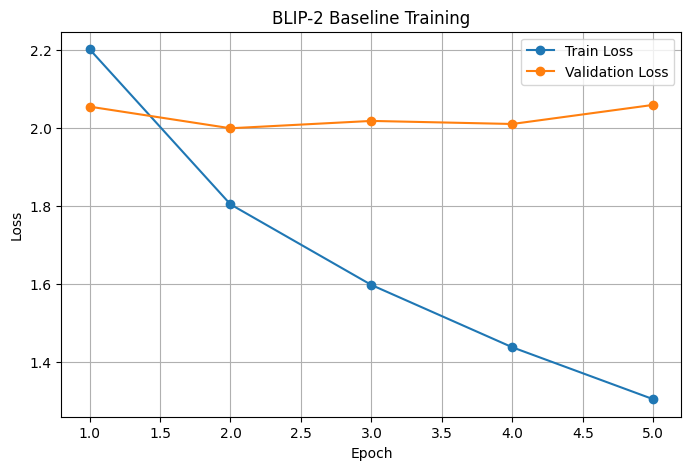

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, EPOCHS + 1),
    train_losses,
    marker="o",
    label="Train Loss"
)

plt.plot(
    range(1, EPOCHS + 1),
    val_losses,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("BLIP-2 Baseline Training")

plt.legend()
plt.grid()

plt.show()

In [ ]:
def generate_caption(
    model,
    image_path,
    max_new_tokens=30
):
    model.eval()

    # -------------------------
    # Load image
    # -------------------------
    image = Image.open(image_path).convert("RGB")

    pixel_values = image_transform(image)
    pixel_values = pixel_values.unsqueeze(0).to(device)

    # -------------------------
    # ViT
    # -------------------------
    with torch.no_grad():

        vision_output = model.vision_encoder(
            pixel_values
        )

        image_features = (
            vision_output.last_hidden_state[:, 1:, :]
        )

    # -------------------------
    # Q-Former
    # -------------------------
    with torch.no_grad():

        qformer_output = model.qformer(
            image_features
        )

        # -------------------------
        # Projector
        # -------------------------

        visual_embeddings = model.projector(
            qformer_output
        )

        visual_embeddings = visual_embeddings.to(
            dtype=model.llm.dtype
        )

        # -------------------------
        # Generate
        # -------------------------

        generated_ids = model.llm.generate(
            inputs_embeds=visual_embeddings,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            num_beams=1,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id
        )

    caption = tokenizer.decode(
        generated_ids[0],
        skip_special_tokens=True
    )

    return caption

In [ ]:
for i in range(5):

    sample = val_df.iloc[i]

    generated_caption = generate_caption(
        model,
        sample["image_path"]
    )

    print("=" * 80)

    print("Image:", sample["image"])

    print("\nActual:")
    print(sample["caption"])

    print("\nGenerated:")
    print(generated_caption)

Image: 114051287_dd85625a04.jpg

Actual:
A boy dressed in soccer attire and holding his shoes getting out of a car .

Generated:
A man is holding a camera and looking at a man who is holding a flashlight and looking at a man who is holding a camera . .
Image: 114051287_dd85625a04.jpg

Actual:
A boy in a red soccer strip is holding his boots in his hand whilst stepping out of a car .

Generated:
A man is holding a camera and looking at a man who is holding a flashlight and looking at a man who is holding a camera . .
Image: 114051287_dd85625a04.jpg

Actual:
A boy in glasses is wearing a red shirt .

Generated:
A man is holding a camera and looking at a man who is holding a flashlight and looking at a man who is holding a camera . .
Image: 114051287_dd85625a04.jpg

Actual:
A child getting out of the car wearing soccer shoes .

Generated:
A man is holding a camera and looking at a man who is holding a flashlight and looking at a man who is holding a camera . .
Image: 114051287_dd85625a04.

In [ ]:
sample = val_df.iloc[0]

for i in range(5):

    caption = generate_caption(
        model,
        sample["image_path"]
    )

    print(f"{i+1}: {caption}")

1: A man is holding a camera and looking at a man who is holding a flashlight and looking at a man who is holding a camera . .
2: A man is holding a camera and looking at a man who is holding a flashlight and looking at a man who is holding a camera . .
3: A man is holding a camera and looking at a man who is holding a flashlight and looking at a man who is holding a camera . .
4: A man is holding a camera and looking at a man who is holding a flashlight and looking at a man who is holding a camera . .
5: A man is holding a camera and looking at a man who is holding a flashlight and looking at a man who is holding a camera . .


In [ ]:
!pip install -q nltk rouge-score

  Preparing metadata (setup.py) ... done


In [ ]:
import nltk

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
from nltk.translate.bleu_score import (
    sentence_bleu,
    SmoothingFunction
)
from nltk.translate.meteor_score import meteor_score

from rouge_score import rouge_scorer


smoothie = SmoothingFunction().method4

rouge = rouge_scorer.RougeScorer(
    ["rougeL"],
    use_stemmer=True
)


def calculate_caption_metrics(reference, generated):

    # Tokenize
    reference_tokens = reference.lower().split()
    generated_tokens = generated.lower().split()

    # BLEU
    bleu1 = sentence_bleu(
        [reference_tokens],
        generated_tokens,
        weights=(1, 0, 0, 0),
        smoothing_function=smoothie
    )

    bleu2 = sentence_bleu(
        [reference_tokens],
        generated_tokens,
        weights=(0.5, 0.5, 0, 0),
        smoothing_function=smoothie
    )

    bleu3 = sentence_bleu(
        [reference_tokens],
        generated_tokens,
        weights=(1/3, 1/3, 1/3, 0),
        smoothing_function=smoothie
    )

    bleu4 = sentence_bleu(
        [reference_tokens],
        generated_tokens,
        weights=(0.25, 0.25, 0.25, 0.25),
        smoothing_function=smoothie
    )

    # METEOR
    meteor = meteor_score(
        [reference_tokens],
        generated_tokens
    )

    # ROUGE-L
    rouge_result = rouge.score(
        reference,
        generated
    )

    rouge_l = rouge_result["rougeL"].fmeasure

    return {
        "BLEU-1": bleu1,
        "BLEU-2": bleu2,
        "BLEU-3": bleu3,
        "BLEU-4": bleu4,
        "METEOR": meteor,
        "ROUGE-L": rouge_l
    }

In [ ]:
import pandas as pd
from tqdm.auto import tqdm


NUM_EVAL_IMAGES = 100

eval_df = (
    val_df
    .drop_duplicates("image")
    .sample(
        n=NUM_EVAL_IMAGES,
        random_state=42
    )
    .reset_index(drop=True)
)

In [ ]:
all_results = []

for i in tqdm(
    range(len(eval_df)),
    desc="Evaluating captions"
):

    row = eval_df.iloc[i]

    generated = generate_caption(
        model,
        row["image_path"]
    )

    reference = row["caption"]

    metrics = calculate_caption_metrics(
        reference,
        generated
    )

    result = {
        "image": row["image"],
        "reference": reference,
        "generated": generated,
        **metrics
    }

    all_results.append(result)

Evaluating captions:   0%|          | 0/100 [00:00<?, ?it/s]

In [ ]:
results_df = pd.DataFrame(all_results)

results_df.head()

,image,reference,generated,BLEU-1,BLEU-2,BLEU-3,BLEU-4,METEOR,ROUGE-L
0,3126225245_96cd2c053f.jpg,A little kid in a striped shirt on a purple fl...,"A man in a black suit , with a red cape , is j...",0.185185,0.084395,0.045452,0.028336,0.132275,0.238095
1,179829865_095b040377.jpg,A man beginning to waterski wearing a red life...,A man in a black wetsuit is jumping off a clif...,0.160000,0.081650,0.045355,0.028743,0.161290,0.181818
2,2363419943_717e6b119d.jpg,A lady and her little girl are holding hands a...,A girl in a red hat and a boy in a blue shirt ...,0.269231,0.059234,0.028771,0.017042,0.217391,0.256410
3,3632258003_6a0a69bf3a.jpg,A group of men with shovels are digging in salt .,A boy in a yellow shirt and blue pants is hold...,0.115385,0.038778,0.021692,0.013789,0.120000,0.117647
4,3369354061_2bab79f91f.jpg,A blonde baby girl in green is walking and hol...,A little girl in a white shirt and a pink hat ...,0.200000,0.091287,0.048858,0.030392,0.176056,0.285714


In [ ]:
metric_names = [
    "BLEU-1",
    "BLEU-2",
    "BLEU-3",
    "BLEU-4",
    "METEOR",
    "ROUGE-L"
]

overall_metrics = results_df[metric_names].mean()

print("\n========== OVERALL METRICS ==========\n")

for metric, score in overall_metrics.items():
    print(f"{metric:10s}: {score:.4f}")


========== OVERALL METRICS ==========

BLEU-1    : 0.2015
BLEU-2    : 0.0985
BLEU-3    : 0.0572
BLEU-4    : 0.0362
METEOR    : 0.2368
ROUGE-L   : 0.2384


In [ ]:
pd.set_option("display.max_colwidth", 200)

results_df[
    [
        "image",
        "reference",
        "generated",
        "BLEU-1",
        "BLEU-4",
        "METEOR",
        "ROUGE-L"
    ]
].head(20)

,image,reference,generated,BLEU-1,BLEU-4,METEOR,ROUGE-L
0,3126225245_96cd2c053f.jpg,A little kid in a striped shirt on a purple floor is getting excited at chasing bubbles .,"A man in a black suit , with a red cape , is jumping in the air while a group of people watch him in a par",0.185185,0.028336,0.132275,0.238095
1,179829865_095b040377.jpg,A man beginning to waterski wearing a red life jacket .,A man in a black wetsuit is jumping off a cliff into the water below . There are two other people in the background .,0.160000,0.028743,0.161290,0.181818
2,2363419943_717e6b119d.jpg,A lady and her little girl are holding hands and walking up the sidewalk .,"A girl in a red hat and a boy in a blue shirt are walking down the street with a sign that says ""Free Hugs .",0.269231,0.017042,0.217391,0.256410
3,3632258003_6a0a69bf3a.jpg,A group of men with shovels are digging in salt .,A boy in a yellow shirt and blue pants is holding a small metal rod and a boy is holding a large metal rod .\n .,0.115385,0.013789,0.120000,0.117647
4,3369354061_2bab79f91f.jpg,A blonde baby girl in green is walking and holding a box .,"A little girl in a white shirt and a pink hat , running along side a woman in a red shirt , on a sidewalk",0.200000,0.030392,0.176056,0.285714
5,3293596075_973b0bfd08.jpg,A black and brown dog walking in deep snow .,A black dog is running through the snowy forest with a red collar on its neck and a red leash in its mouth .\n Snow,0.280000,0.033059,0.304348,0.303030
6,2748435417_ea7bbcc17c.jpg,A skateboarder performs a trick in front of a business building .,A man in a black and white striped shirt is jumping off a ledge and landing on a concrete floor with a skateboard,0.173913,0.016411,0.190840,0.176471
7,381514859_b40418d9c3.jpg,Two small white dogs are in a yard chasing a red ball .,A woman in a white dog is running across a green grass field with a red ball in her mouth and a blue ribbon around her neck .,0.250000,0.061430,0.435345,0.307692
8,426065353_e9a604a01f.jpg,A couple guys taking body shots off of a girl,A man in a black suit and a woman in a red dress are standing in front of a large stone wall with a large stone statue in the,0.103448,0.023372,0.126050,0.153846
9,255091927_2eb643beb2.jpg,People laying in massage chairs,A man and a woman are sitting on a couch with a laptop in front of them and a man is standing behind them with a drink .,0.035714,0.009850,0.068493,0.062500


In [ ]:
results_df.sample(
    10,
    random_state=10
)[
    [
        "reference",
        "generated",
        "BLEU-4",
        "METEOR",
        "ROUGE-L"
    ]
]

,reference,generated,BLEU-4,METEOR,ROUGE-L
19,A blond girl standing in a crowd holding a goat on a leash .,"A man and a woman are standing in front of a group of dogs , all wearing collars and leashes , and standing in a",0.059724,0.317610,0.277778
14,"The two boys , one in orange the other in teal , wrestle in the sand .",A little girl in a white shirt and a little girl in a pink shirt are playing with a ball in a sandbox .\n,0.015839,0.112994,0.162162
43,A girl holds something while three dogs beg .,A dog standing on a brown dog with a collar and a leash is standing on a green hill with a blue sky in the background .,0.012074,0.185185,0.117647
37,A man in a blue shirt lifts up his tennis racket and smiles .,A man in a black and white striped shirt is holding a yellow ball and looking at the umpire while the other players are in,0.104352,0.198675,0.315789
66,a dog running on the beach,"A black dog with a white collar , is running on the beach with a beach ball in his mouth , and a beach umbrella in",0.100084,0.638889,0.400000
3,A group of men with shovels are digging in salt .,A boy in a yellow shirt and blue pants is holding a small metal rod and a boy is holding a large metal rod .\n .,0.013789,0.120000,0.117647
79,A brown toy dog is running across low snow with tail raised .,A black dog is running through the snow with a white dog in the background . The dog is wearing a red collar and a red le,0.063668,0.438368,0.315789
41,a lone person in a harness climbing a huge rock .,A man in a red shirt and blue pants is climbing a rocky cliff with a rope around his waist and a,0.040615,0.206612,0.312500
38,A girl and woman jump off of their swings .,A boy in a blue shirt and blue pants is hanging from a swing on a metal pole in a grassy area .\n .,0.014740,0.175439,0.193548
68,A surfer rides the crashing waves while another follows behind .,A surfer in a black wetsuit is riding a wave on a surfboard and doing a flip in the air .\n,0.033705,0.291667,0.266667


In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

# Randomly select 100 unique validation images
random_samples = (
    val_df
    .drop_duplicates("image")
    .sample(n=100, random_state=42)
    .reset_index(drop=True)
)

for i, sample in random_samples.iterrows():

    # Generate caption
    generated_caption = generate_caption(
        model,
        sample["image_path"]
    )

    # Load original image
    image = Image.open(
        sample["image_path"]
    ).convert("RGB")

    # Display image
    plt.figure(figsize=(10, 7))
    plt.imshow(image)
    plt.axis("off")

    plt.title(
        f"Actual:\n{sample['caption']}\n\n"
        f"Generated:\n{generated_caption}",
        fontsize=11
    )

    plt.show()

    print("=" * 100)
    print(f"IMAGE {i + 1}: {sample['image']}")
    print("=" * 100)